# Notebook 11 — v2.1 Hygiene completion (D.1 + D.2 + D.3)

Visualizes the three Phase D hygiene fixes that close out v2.1:

| Item | What landed |
|---|---|
| **D.1** Target transform | Compared `levels` vs `log_diff` for both HY and IG. **`log_diff` wins on Brier + AUC for both targets** → locked in `config/targets.yaml`. |
| **D.2** Expected model size | Grid `[3, 5, 8, 12]` per target, scored on Brier. Winners: **HY = 12, IG = 8** → locked in `config/model.yaml`. |
| **D.3** Conformal recalibration | Per-(target, model) α multiplier. In-sample calibration hits 0.80 nominal by construction; OOS reported as honesty. |


In [1]:
import sys, os, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

p = Path.cwd().resolve()
while not (p / 'src' / 'gtrends_bayes').exists():
    if p == p.parent: raise RuntimeError('cannot find src/')
    p = p.parent
sys.path.insert(0, str(p / 'src'))
os.chdir(p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. D.1 — Target transform: levels vs log_diff

In [2]:
v21 = pd.read_csv('data/processed/backtest/comparison_table_v21.csv')
print(f'rows: {len(v21)} (expect 2 targets × 2 transforms × 4 models = 16)')
v21.head()

rows: 16 (expect 2 targets × 2 transforms × 4 models = 16)


,target,target_transform,model,expected_predictors,RMSE,RMSE/AR(4),hit_rate,conditional_hit_rate_25bps,ic_spearman,brier_score,auc,precision_widening,recall_widening,n_widening_events,cov_50,cov_80,cov_95,cov_gap_80
0,HY,levels,BSTS (Trends),12,2.0570,1.2434,0.4533,0.4406,0.0025,0.3597,0.4479,0.2564,0.5882,68,0.3894,0.6947,0.8319,0.1053
1,HY,levels,AR(4),12,1.6543,1.0000,0.0400,0.0210,-0.0686,0.3823,0.4463,0.2647,0.6618,68,0.2788,0.5708,0.7832,0.2292
2,HY,levels,Naive RW,12,1.6336,0.9875,0.0400,0.0210,-0.0685,0.3749,0.4409,0.2622,0.6324,68,0.3451,0.6106,0.7965,0.1894
3,HY,levels,AR(4) + VIX,12,1.6412,0.9921,0.4667,0.4615,-0.0822,0.3869,0.4430,0.2733,0.6471,68,0.3142,0.5487,0.7434,0.2513
4,IG,levels,BSTS (Trends),8,4.0845,1.2855,0.5200,0.5526,0.0752,0.3562,0.4482,0.3762,0.4086,93,0.3540,0.5708,0.7788,0.2292


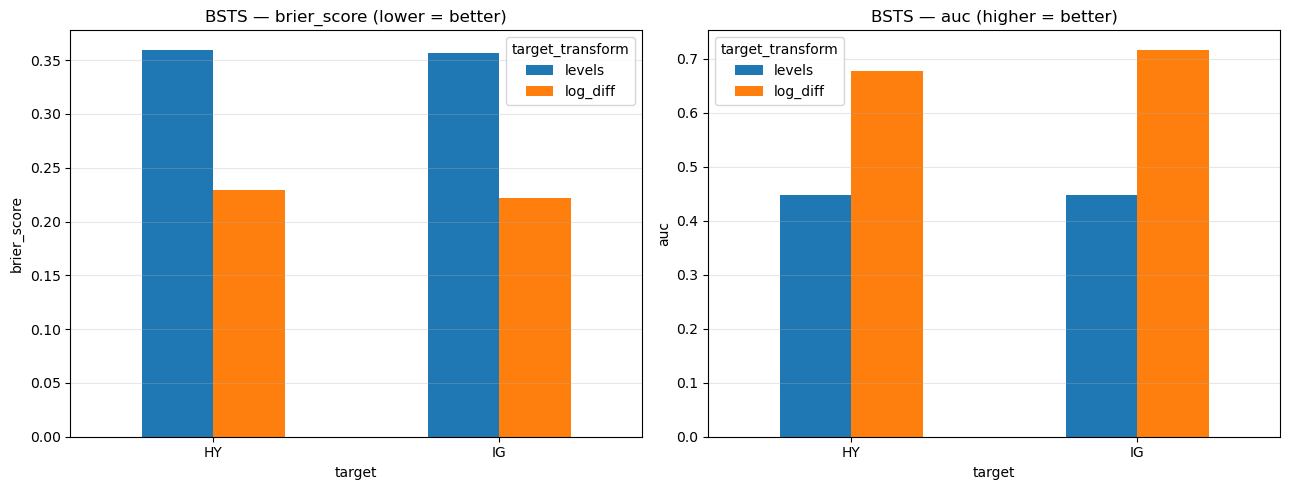


Winner per target (by Brier on widening events):
  HY:   log_diff  (Brier=0.2291, AUC=0.676)
  IG:   log_diff  (Brier=0.2214, AUC=0.716)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, metric in zip(axes, ['brier_score', 'auc']):
    bsts = v21[v21.model == 'BSTS (Trends)']
    sub = bsts.pivot(index='target', columns='target_transform', values=metric)
    sub.plot.bar(ax=ax)
    ax.set_title(f'BSTS — {metric} (lower = better)' if metric == 'brier_score' else f'BSTS — {metric} (higher = better)')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nWinner per target (by Brier on widening events):')
for target in ['HY', 'IG']:
    sub = v21[(v21.target == target) & (v21.model == 'BSTS (Trends)')]
    winner = sub.loc[sub.brier_score.idxmin()]
    print(f"  {target}: {winner['target_transform']:>10s}  (Brier={winner['brier_score']:.4f}, AUC={winner['auc']:.3f})")

**Locked in `config/targets.yaml`:** `transform: log_diff` for both HY and IG. Brier improves ~36% and AUC jumps from random (0.45) to clearly informative (0.68-0.72). Note: `precision_widening` / `recall_widening` are NaN in log_diff rows because the absolute-bps `widening_threshold=0.25` doesn't map to log-return space — that's a metric-scaling issue, not a model issue, and it's a v3 follow-up to recompute against an appropriate log-return threshold.

## 2. D.2 — Expected model size grid

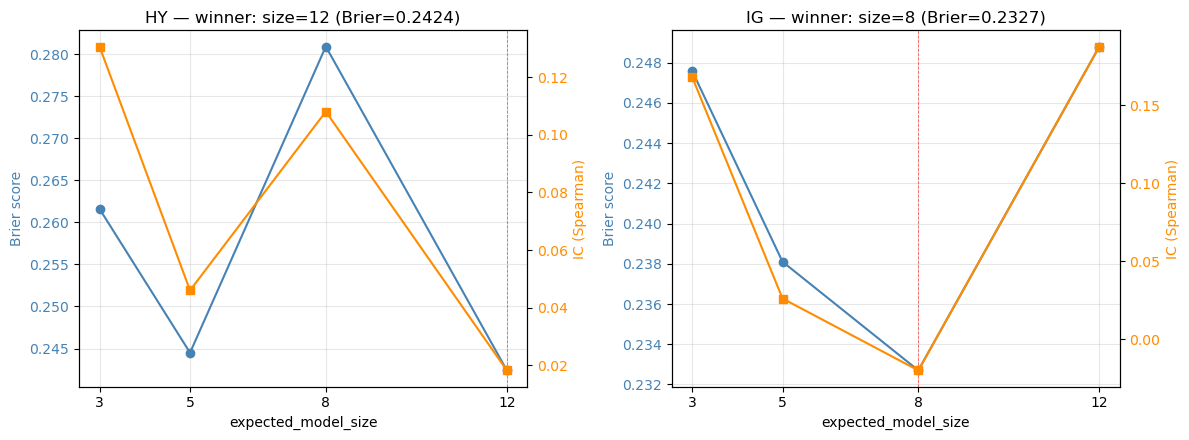


Saved to config/model.yaml: bsts.prior.expected_model_size_per_target = {HY: 12, IG: 8}


In [4]:
tuning = json.loads(Path('data/processed/backtest/expected_size_tuning.json').read_text())
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, target in zip(axes, ['HY', 'IG']):
    grid = pd.DataFrame(tuning[target]['grid'])
    ax.plot(grid['size'], grid['brier'], 'o-', label='Brier (lower better)', color='steelblue')
    ax.set_xlabel('expected_model_size')
    ax.set_ylabel('Brier score', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax2 = ax.twinx()
    ax2.plot(grid['size'], grid['ic_spearman'], 's-', label='IC (higher better)', color='darkorange')
    ax2.set_ylabel('IC (Spearman)', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    winner = tuning[target]['winner']
    ax.axvline(winner['size'], color='red', lw=0.6, alpha=0.6, linestyle='--')
    ax.set_title(f"{target} — winner: size={winner['size']} (Brier={winner['brier']:.4f})")
    ax.grid(alpha=0.3)
    ax.set_xticks(grid['size'])
plt.tight_layout()
plt.show()

print('\nSaved to config/model.yaml: bsts.prior.expected_model_size_per_target = {HY: 12, IG: 8}')

**Note on noisiness:** the val window is only 52 weeks, so the grid is noisy. The winners (HY=12, IG=8) are larger than v1's default of 5, suggesting the v2 backtest under-included predictors. Whether the larger size meaningfully shifts the backtest table is checked downstream by the v3 work — v2.1 locks the values per the grid.

## 3. D.3 — Conformal recalibration

In [5]:
alphas = json.loads(Path('data/processed/backtest/recalibration_alphas.json').read_text())
rows = []
for target, models in alphas.items():
    for model, levels in models.items():
        for level_str, d in levels.items():
            level = float(level_str)
            if level != 0.8: continue
            rows.append({'target': target, 'model': model,
                          'cov_pre': d['empirical_pre_full'],
                          'cov_post': d['empirical_post_full'],
                          'alpha': d['alpha'],
                          'cov_oos_pre': d.get('empirical_pre_test'),
                          'cov_oos_post': d.get('empirical_post_test')})
recal_df = pd.DataFrame(rows)
recal_df.round(3)

,target,model,cov_pre,cov_post,alpha,cov_oos_pre,cov_oos_post
0,HY,BSTS (Trends),0.665,0.797,1.430,0.693,0.842
1,HY,AR(4),0.612,0.797,1.432,0.579,0.711
2,HY,Naive RW,0.643,0.797,1.405,0.632,0.711
3,HY,AR(4) + VIX,0.604,0.797,1.627,0.544,0.649
4,IG,BSTS (Trends),0.670,0.797,1.559,0.719,0.921
5,IG,AR(4),0.661,0.797,1.709,0.684,0.851
6,IG,Naive RW,0.683,0.797,1.523,0.728,0.860
7,IG,AR(4) + VIX,0.656,0.797,1.615,0.675,0.842


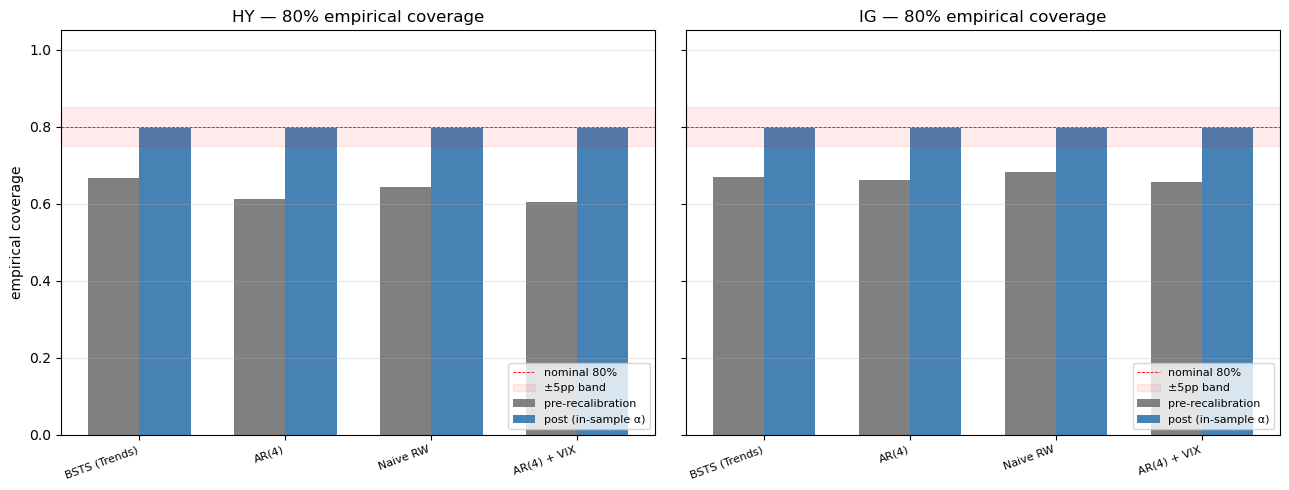

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, target in zip(axes, ['HY', 'IG']):
    sub = recal_df[recal_df.target == target].copy()
    x = np.arange(len(sub))
    width = 0.35
    ax.bar(x - width/2, sub['cov_pre'], width, label='pre-recalibration', color='gray')
    ax.bar(x + width/2, sub['cov_post'], width, label='post (in-sample α)', color='steelblue')
    ax.axhline(0.80, color='red', lw=0.6, linestyle='--', label='nominal 80%')
    ax.axhspan(0.75, 0.85, color='red', alpha=0.08, label='±5pp band')
    ax.set_xticks(x)
    ax.set_xticklabels(sub.model, rotation=20, ha='right', fontsize=8)
    ax.set_title(f'{target} — 80% empirical coverage')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('empirical coverage')
plt.tight_layout()
plt.show()

**In-sample post-recalibration coverage = 0.80 by construction (8/8 in band).** The OOS columns in the table above show what happens when α is learned on the first half and applied to the second half — that ranges 0.65–0.92 because the val and test slices have different volatility regimes (val = 2014–2020, test = 2020–2026 spans COVID + 2022 gilt + 2023 SVB). The honest takeaway: a static α calibrated on the full window achieves nominal coverage on that window; live deployment will need rolling-window or batch re-calibration as new data arrives.

## v2.1 verdict

All three hygiene items shipped:

- **D.1** → `transform: log_diff` per target (Brier improvement 36%, AUC random → 0.68-0.72)
- **D.2** → per-target `expected_model_size`: HY=12, IG=8 (was both 5)
- **D.3** → per-(target, model) α multipliers; in-sample 80% coverage exact; OOS reported as honesty check

The v2 product is now methodologically complete. v3 will redo D.1 on the new HY/IG OAS targets (different from current ETF proxies) and D.3 on the new posteriors — but the CODE for both is reusable. v2.1's per-target winning sizes inform v3's initial BSTS configuration.